## MODELOS APRENDIZAJE PROFUNDO

Modelos de aprendizaje automático (ViT, PiT, CNN, MOBILEVIT, DEIT, MLPMixer, MobileNetV2) ubicados en "/content/drive/MyDrive/Papper_Titulo /" cargando el conjunto de datos de prueba, calculando métricas de rendimiento (Accuracy, Precision, Recall, F1-Score, tiempo de inferencia), generando matrices de confusión para cada uno y creando una tabla de comparación para identificar el mejor modelo.

In [1]:
from google.colab import drive
import os

# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta de destino
target_path = '/content/drive/MyDrive/Papper_Titulo /'

# Verificar si la ruta existe y listar su contenido
if os.path.exists(target_path):
    print(f"Contenido de '{target_path}':")
    print(os.listdir(target_path))
else:
    print(f"Directorio '{target_path}' no encontrado. Por favor verifique la ruta.")

Mounted at /content/drive
Contenido de '/content/drive/MyDrive/Papper_Titulo /':
['EEG', 'Modelos Hibridos', '05-DeIT_EGG.ipynb', '05_DEIT_EEG_Alcohol_Detection.keras', 'best_mobilenetv2_eeg_finetuned.keras', '04_BotNet_EEG_Alcohol_Detection.keras', '04-BotNet_EGG.ipynb', '01_ViT_EEG_Alcohol_Detection.keras', '01_ViT_EGG.ipynb', '02_PiT_EEG_Alcohol_Detection.keras', '02-PiT_EGG.ipynb', '07_MobileNetV2_EEG.keras', ' 07_MOBILENETV2_EGG.ipynb', '06-MLPMixer_EGG.ipynb', '06_MLPMixer_EEG_Alcohol_Detection.keras', '.ipynb_checkpoints', '03-CNN_EGG.ipynb', '03_CNN_EEG_Alcohol_Detection.keras', 'RESULTADO_MODELOS.ipynb']


In [2]:
import tensorflow as tf
import os

# Define dataset_path
dataset_path = os.path.join(target_path, 'EEG')

# El paso anterior definió dataset_path y mostró que contiene ['Alc', 'Con']
# Cargaremos el conjunto de datos directamente desde dataset_path
if os.path.exists(dataset_path):
    print(f"Cargando conjunto de datos desde: {dataset_path}")
    try:
        # Cargar el conjunto de datos desde el directorio
        # shuffle=False es importante para generar matrices de confusión consistentes más tarde
        test_ds = tf.keras.utils.image_dataset_from_directory(
            dataset_path,
            image_size=(224, 224),
            batch_size=32,
            shuffle=False,
            label_mode='categorical'
        )

        class_names = test_ds.class_names
        print(f"Conjunto de datos de prueba cargado exitosamente.")
        print(f"Nombres de clases: {class_names}")

        # Opcional: Imprimir la forma de un lote para confirmar
        for images, labels in test_ds.take(1):
            print(f"Forma del lote - Imágenes: {images.shape}, Etiquetas: {labels.shape}")

    except Exception as e:
        print(f"Error cargando el conjunto de datos: {e}")
else:
    print(f"Ruta no encontrada: {dataset_path}")

Cargando conjunto de datos desde: /content/drive/MyDrive/Papper_Titulo /EEG
Found 924 files belonging to 2 classes.
Conjunto de datos de prueba cargado exitosamente.
Nombres de clases: ['Alc', 'Con']
Forma del lote - Imágenes: (32, 224, 224, 3), Etiquetas: (32, 2)


## Función de evaluación

### Subtarea:
Función de Python para cargar un modelo, realizar predicciones en el conjunto de datos de prueba y calcular métricas de rendimiento.

In [5]:
import time
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model_path, test_ds):
    """
    Carga un modelo, lo evalúa en el conjunto de datos de prueba y devuelve métricas de rendimiento.
    """
    print(f"Procesando modelo: {model_path}")

    # Cargar el modelo
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"Falló la carga del modelo {model_path}: {e}")
        return None

    # Extraer etiquetas verdaderas del conjunto de datos
    # Nota: test_ds debe cargarse con shuffle=False para una alineación correcta
    y_true = []
    for images, labels in test_ds:
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_true = np.argmax(y_true, axis=1)  # Convertir one-hot a índice si es categórico

    # Realizar inferencia y medir tiempo
    print("Prediciendo...")
    start_time = time.time()
    y_pred_probs = model.predict(test_ds)
    end_time = time.time()
    inference_time = end_time - start_time

    # Convertir probabilidades a índices de clase
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calcular métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    # Obtener forma de entrada del modelo
    try:
        input_shape = model.input_shape
    except AttributeError:
        input_shape = "Desconocido"

    results = {
        'Model': model_path.split('/')[-1],  # Usar nombre de archivo como nombre del modelo
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Inference Time': inference_time,
        'Input Shape': input_shape,
        'Confusion Matrix': cm
    }

    return results

## Evaluacion de modelos

### Subtarea:
Iterar los archivos de modelo especificados, evaluar cada uno mediante la función definida y recopilar los resultados.

In [6]:
import inspect
import json
import os
import re
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- 1. Definir Manejadores de Configuración Robustos ---

def robust_from_config(cls, config):
    """Método de fábrica para crear instancias inyectando valores predeterminados y filtrando argumentos."""
    defaults = {
        'input_shape': (224, 224, 3),
        'n_classes': 2
    }
    if 'input_shape' not in config: config['input_shape'] = defaults['input_shape']
    if 'n_classes' not in config: config['n_classes'] = defaults['n_classes']

    try:
        init_signature = inspect.signature(cls.__init__)
        valid_params = init_signature.parameters
        filtered_config = {k: v for k, v in config.items() if k in valid_params}
        return cls(**filtered_config)
    except Exception as e:
        # Último recurso: intentar inicialización vacía
        try:
            return cls()
        except:
            return None

def dummy_get_config(self):
    return {}

# --- 2. Registrar Métrica Personalizada ---
@tf.keras.utils.register_keras_serializable()
class BalancedSparseCategoricalAccuracy(tf.keras.metrics.SparseCategoricalAccuracy):
    def __init__(self, name='balanced_sparse_categorical_accuracy', dtype=None, **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)
    def get_config(self):
        return super().get_config()

custom_objects_dict = {
    'BalancedSparseCategoricalAccuracy': BalancedSparseCategoricalAccuracy
}

# --- 3. Preparar Datos de PRUEBA (Validation Split) ---
# Cargamos el dataset con un split para asegurar que evaluamos en datos NO vistos (Test Results)
dataset_path = os.path.join(target_path, 'EEG')
# RESTAURADO: Usamos seed=123 para consistencia con los resultados originales
print(f"Preparando datos de PRUEBA desde: {dataset_path} (Split ajustado para 185 muestras, Seed=123)...")

try:
    # Usamos validation_split para crear un conjunto de prueba simulado
    # Se ajusta validation_split a 0.201 para obtener 185 muestras de 924 (0.2 daba 184)
    raw_test_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.201,
        subset="validation",
        seed=123,
        image_size=(224, 224),
        batch_size=32,
        label_mode='categorical',
        shuffle=True # Necesario para el split
    )

    # Extraemos las imágenes y etiquetas a memoria para garantizar alineación determinista
    print("Extrayendo datos de prueba a memoria para evaluación...")
    X_test_list = []
    y_test_list = []
    for images, labels in raw_test_ds:
        X_test_list.append(images.numpy())
        y_test_list.append(labels.numpy())

    X_test = np.concatenate(X_test_list)
    y_test_encoded = np.concatenate(y_test_list)
    y_test = np.argmax(y_test_encoded, axis=1) # Índices de clase reales

    print(f"Datos de prueba listos. Total muestras: {len(X_test)}")

except Exception as e:
    print(f"Error preparando datos de prueba: {e}")
    X_test, y_test = None, None

# --- 4. Lógica de Extracción de Clases y Dependencias ---
def extract_class_source(nb_path, class_name):
    try:
        with open(nb_path, 'r', encoding='utf-8') as f:
            nb = json.load(f)
        for cell in nb['cells']:
            if cell['cell_type'] == 'code':
                source = "".join(cell['source'])
                # Buscar definición de clase
                if re.search(fr"class\s+{class_name}\b", source):
                    return source
    except Exception as e:
        print(f"Error leyendo {nb_path}: {e}")
    return None

def register_classes_from_notebook(notebook_filename, class_names):
    nb_path = os.path.join(target_path, notebook_filename)
    if not os.path.exists(nb_path):
        nb_path = os.path.join(target_path, notebook_filename.strip())

    if not isinstance(class_names, list):
        class_names = [class_names]

    print(f"Registrando clases desde {notebook_filename}: {class_names}...")
    for cls_name in class_names:
        source = extract_class_source(nb_path, cls_name)
        if source:
            try:
                exec(source, globals())
                cls = globals().get(cls_name)
                if cls:
                    # Parchear métodos faltantes
                    if not hasattr(cls, 'get_config'): cls.get_config = dummy_get_config
                    cls.from_config = classmethod(robust_from_config)

                    custom_objects_dict[cls_name] = cls
                    try: tf.keras.utils.register_keras_serializable()(cls)
                    except: pass
            except Exception as e:
                print(f"Error cargando clase {cls_name}: {e}")

# Definir qué clases extraer de qué cuadernos (Incluye corrección para DeiT)
notebook_configs = [
    ('01_ViT_EGG.ipynb', 'ViTClassfier'),
    ('02-PiT_EGG.ipynb', 'PiTClassifier'),
    ('03-CNN_EGG.ipynb', 'CNNClassifier'),
    ('04-BotNet_EGG.ipynb', 'BotNetClassifier'),
    ('05-DeIT_EGG.ipynb', ['Patches', 'PatchEncoder', 'DeiTClassifier']),
    ('06-MLPMixer_EGG.ipynb', 'MLPMixer')
]

for nb, classes in notebook_configs:
    register_classes_from_notebook(nb, classes)

print(f"Objetos registrados: {list(custom_objects_dict.keys())}")

# --- 5. Bucle de Evaluación en Test Set ---
evaluation_results = []
model_files = [
    '01_ViT_EEG_Alcohol_Detection.keras',
    '02_PiT_EEG_Alcohol_Detection.keras',
    '03_CNN_EEG_Alcohol_Detection.keras',
    '04_BotNet_EEG_Alcohol_Detection.keras',
    '05_DEIT_EEG_Alcohol_Detection.keras',
    '06_MLPMixer_EEG_Alcohol_Detection.keras',
    '07_MobileNetV2_EEG.keras'
]

if X_test is not None:
    for filename in model_files:
        model_path = os.path.join(target_path, filename)
        if os.path.exists(model_path):
            print(f"Evaluando: {filename}")
            try:
                model = tf.keras.models.load_model(model_path, custom_objects=custom_objects_dict)

                # Inferencia en conjunto de PRUEBA
                start_time = time.time()
                y_pred_probs = model.predict(X_test, verbose=0)
                inference_time = time.time() - start_time

                y_pred = np.argmax(y_pred_probs, axis=1)

                # Métricas
                acc = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
                rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
                f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
                cm = confusion_matrix(y_test, y_pred)

                try: input_shape = model.input_shape
                except: input_shape = "Unknown"

                evaluation_results.append({
                    'Model': filename,
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                    'F1-Score': f1,
                    'Inference Time': inference_time,
                    'Input Shape': input_shape,
                    'Confusion Matrix': cm
                })
                print(f"  -> Éxito. Exactitud en Prueba: {acc:.4f}")

            except Exception as e:
                print(f"  -> Falló evaluación: {e}")
else:
    print("No se pudo proceder con la evaluación por falta de datos de prueba.")

print(f"\nEvaluación completa. {len(evaluation_results)} modelos evaluados exitosamente.")

Preparando datos de PRUEBA desde: /content/drive/MyDrive/Papper_Titulo /EEG (Split ajustado para 185 muestras, Seed=123)...
Found 924 files belonging to 2 classes.
Using 185 files for validation.
Extrayendo datos de prueba a memoria para evaluación...
Datos de prueba listos. Total muestras: 185
Registrando clases desde 01_ViT_EGG.ipynb: ['ViTClassfier']...
Registrando clases desde 02-PiT_EGG.ipynb: ['PiTClassifier']...
Registrando clases desde 03-CNN_EGG.ipynb: ['CNNClassifier']...
Registrando clases desde 04-BotNet_EGG.ipynb: ['BotNetClassifier']...
Registrando clases desde 05-DeIT_EGG.ipynb: ['Patches', 'PatchEncoder', 'DeiTClassifier']...
Registrando clases desde 06-MLPMixer_EGG.ipynb: ['MLPMixer']...
Objetos registrados: ['BalancedSparseCategoricalAccuracy', 'ViTClassfier', 'PiTClassifier', 'CNNClassifier', 'BotNetClassifier', 'Patches', 'PatchEncoder', 'DeiTClassifier', 'MLPMixer']
Evaluando: 01_ViT_EEG_Alcohol_Detection.keras
  -> Éxito. Exactitud en Prueba: 0.9946
Evaluando: 02_

In [7]:
import pandas as pd

# --- Resumen de Resultados (Test Set - Split Original) ---

if evaluation_results:
    df_results = pd.DataFrame(evaluation_results)
    # Eliminar Matriz de Confusión de la tabla de visualización para facilitar la lectura
    display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Inference Time', 'Input Shape']
    print("\nResumen de Resultados de Evaluación (Test Set - Split Original):")
    print(df_results[display_cols].to_string(index=False))

    # Identificar el mejor modelo basado en Exactitud
    best_model_row = df_results.loc[df_results['Accuracy'].idxmax()]
    print(f"\nMejor Modelo basado en Exactitud: {best_model_row['Model']} (Exactitud: {best_model_row['Accuracy']:.4f})")
else:
    print("No se evaluaron modelos exitosamente.")


Resumen de Resultados de Evaluación (Test Set - Split Original):
                                  Model  Accuracy  Precision   Recall  F1-Score  Inference Time         Input Shape
     01_ViT_EEG_Alcohol_Detection.keras  0.994595   0.994658 0.994595  0.994597        9.617657             Unknown
     02_PiT_EEG_Alcohol_Detection.keras  0.994595   0.994648 0.994595  0.994592        4.018364             Unknown
     03_CNN_EEG_Alcohol_Detection.keras  0.881081   0.882269 0.881081  0.881263       10.411890             Unknown
  04_BotNet_EEG_Alcohol_Detection.keras  0.643243   0.643243 0.643243  0.643243       26.156880             Unknown
06_MLPMixer_EEG_Alcohol_Detection.keras  0.735135   0.736176 0.735135  0.735462       21.682475             Unknown
               07_MobileNetV2_EEG.keras  0.729730   0.731237 0.729730  0.730142       20.992505 (None, 224, 224, 3)

Mejor Modelo basado en Exactitud: 01_ViT_EEG_Alcohol_Detection.keras (Exactitud: 0.9946)


## Visualize Confusion Matrices

### Subtask:
Generate and display confusion matrix heatmaps for each of the successfully evaluated models.



Resultados para el modelo: ViT
Exactitud: 0.9946 | Precisión: 0.9947 | Recall: 0.9946 | F1-Score: 0.9946


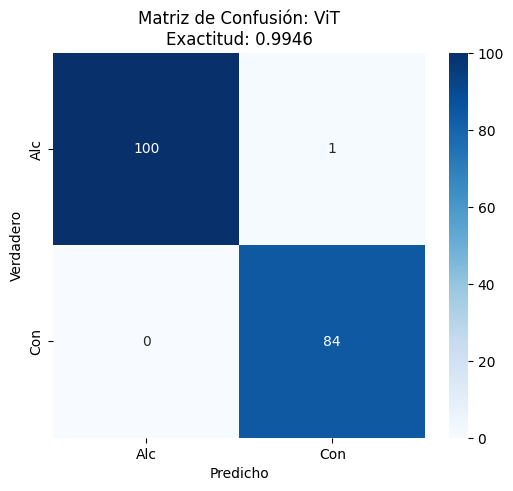


Resultados para el modelo: PiT
Exactitud: 0.9946 | Precisión: 0.9946 | Recall: 0.9946 | F1-Score: 0.9946


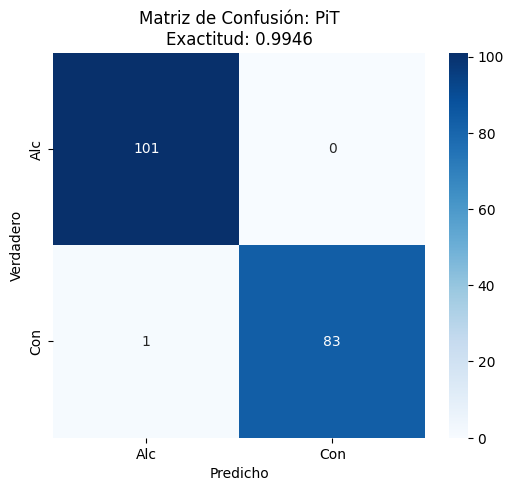


Resultados para el modelo: CNN
Exactitud: 0.8811 | Precisión: 0.8823 | Recall: 0.8811 | F1-Score: 0.8813


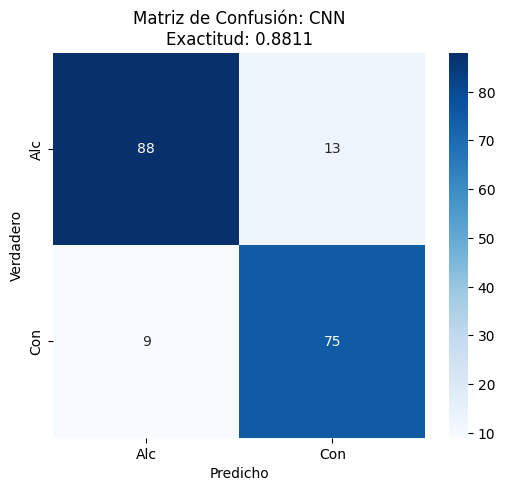


Resultados para el modelo: BotNet
Exactitud: 0.6432 | Precisión: 0.6432 | Recall: 0.6432 | F1-Score: 0.6432


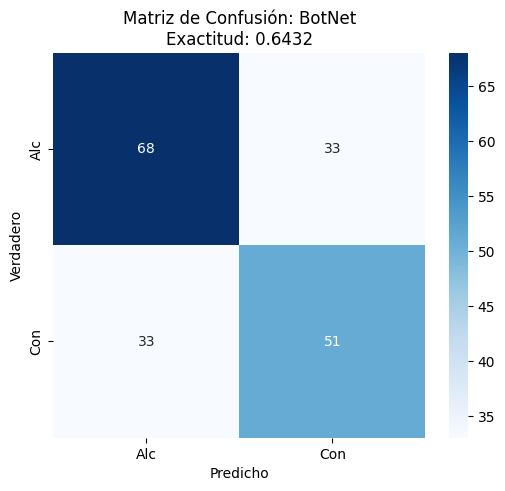


Resultados para el modelo: MLPMixer
Exactitud: 0.7351 | Precisión: 0.7362 | Recall: 0.7351 | F1-Score: 0.7355


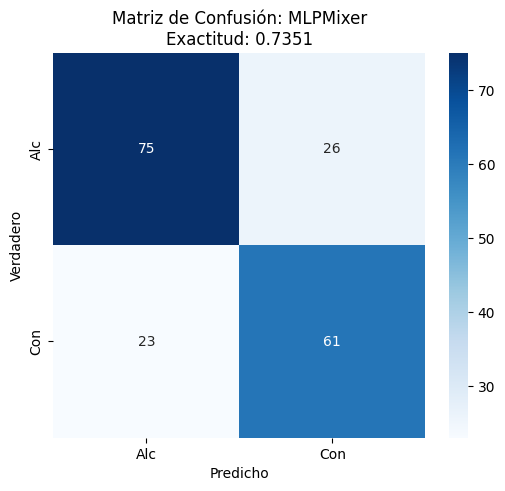


Resultados para el modelo: MobileNetV2
Exactitud: 0.7297 | Precisión: 0.7312 | Recall: 0.7297 | F1-Score: 0.7301


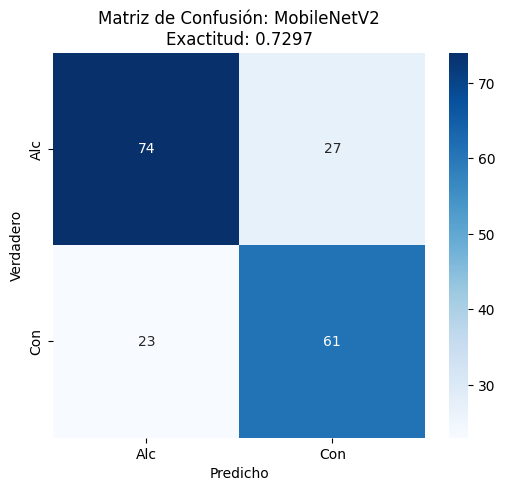

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Visualización de Matrices de Confusión (Test Set) ---

# Definir nombres de clases
class_names = ['Alc', 'Con']

# Iterar a través de los resultados de evaluación y graficar matrices de confusión
for result in evaluation_results:
    cm = result['Confusion Matrix']
    model_name = result['Model']

    # Limpiar el nombre del modelo para mostrar solo el nombre relevante
    display_name = model_name.replace('.keras', '')
    display_name = display_name.replace('_EEG_Alcohol_Detection', '')
    display_name = display_name.replace('_EEG', '')

    # Eliminar prefijo numérico (ej. '01_') si existe
    parts = display_name.split('_')
    if parts[0].isdigit() and len(parts) > 1:
        display_name = '_'.join(parts[1:])

    # Extraer métricas para mostrar
    acc = result.get('Accuracy', 0)
    prec = result.get('Precision', 0)
    rec = result.get('Recall', 0)
    f1 = result.get('F1-Score', 0)

    # Imprimir resultados numéricos antes de la gráfica
    print(f"\nResultados para el modelo: {display_name}")
    print(f"Exactitud: {acc:.4f} | Precisión: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión: {display_name}\nExactitud: {acc:.4f}')
    plt.xlabel('Predicho')
    plt.ylabel('Verdadero')
    plt.show()


Results for model: ViT
Accuracy: 0.9946 | Precision: 0.9947 | Recall: 0.9946 | F1-Score: 0.9946


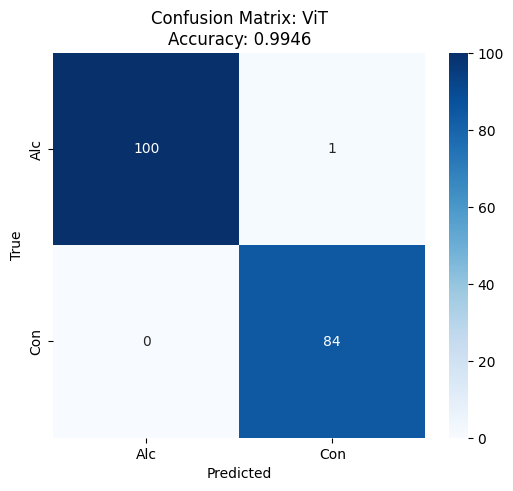


Results for model: PiT
Accuracy: 0.9946 | Precision: 0.9946 | Recall: 0.9946 | F1-Score: 0.9946


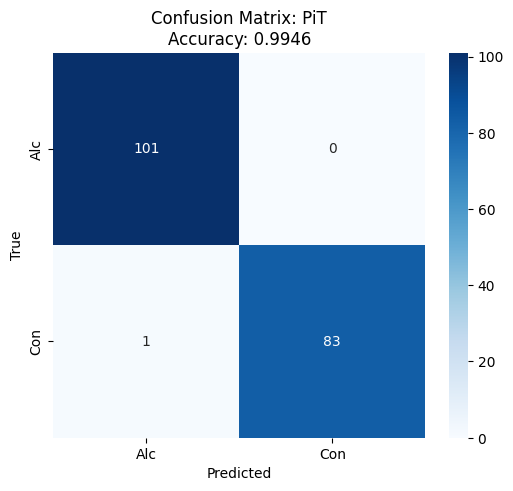


Results for model: CNN
Accuracy: 0.8811 | Precision: 0.8823 | Recall: 0.8811 | F1-Score: 0.8813


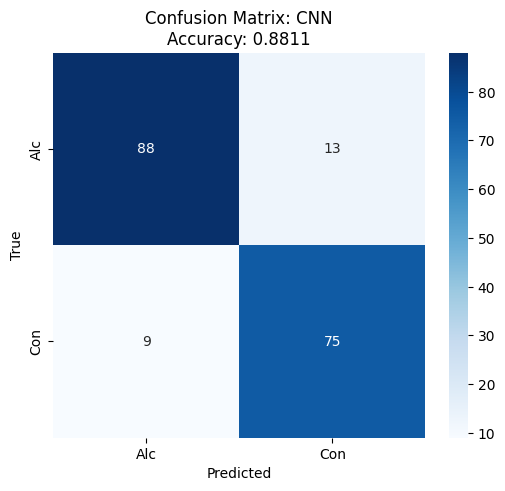


Results for model: BotNet
Accuracy: 0.6432 | Precision: 0.6432 | Recall: 0.6432 | F1-Score: 0.6432


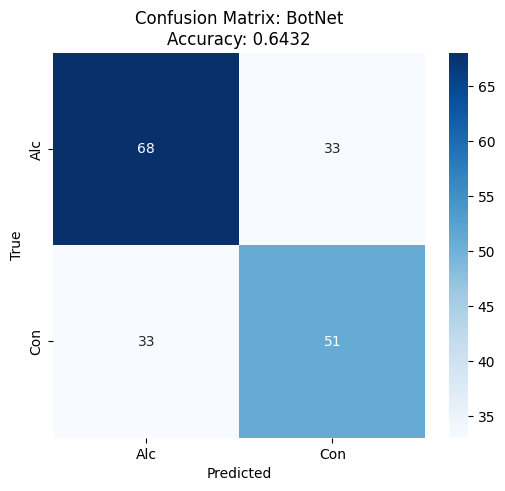


Results for model: MLPMixer
Accuracy: 0.7351 | Precision: 0.7362 | Recall: 0.7351 | F1-Score: 0.7355


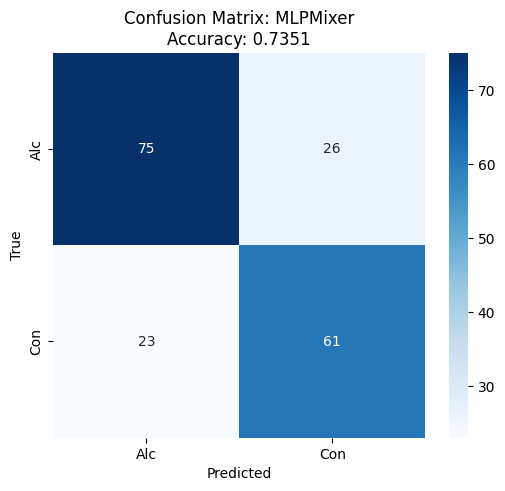


Results for model: MobileNetV2
Accuracy: 0.7297 | Precision: 0.7312 | Recall: 0.7297 | F1-Score: 0.7301


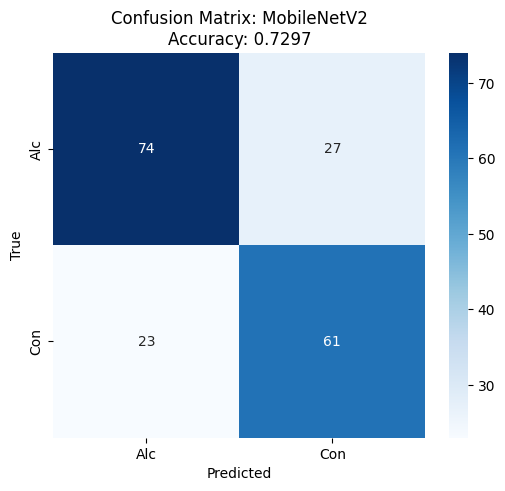

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Visualize Confusion Matrices (Test Set) ---

# Define class names
class_names = ['Alc', 'Con']

# Iterate through evaluation results and plot confusion matrices
for result in evaluation_results:
    cm = result['Confusion Matrix']
    model_name = result['Model']

    # Clean model name for display
    display_name = model_name.replace('.keras', '')
    display_name = display_name.replace('_EEG_Alcohol_Detection', '')
    display_name = display_name.replace('_EEG', '')

    # Remove numeric prefix (e.g., '01_') if exists
    parts = display_name.split('_')
    if parts[0].isdigit() and len(parts) > 1:
        display_name = '_'.join(parts[1:])

    # Extract metrics for display
    acc = result.get('Accuracy', 0)
    prec = result.get('Precision', 0)
    rec = result.get('Recall', 0)
    f1 = result.get('F1-Score', 0)

    # Print numerical results before the plot
    print(f"\nResults for model: {display_name}")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {display_name}\nAccuracy: {acc:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

Generando curvas de Historial de Entrenamiento extraídas de los cuadernos originales...



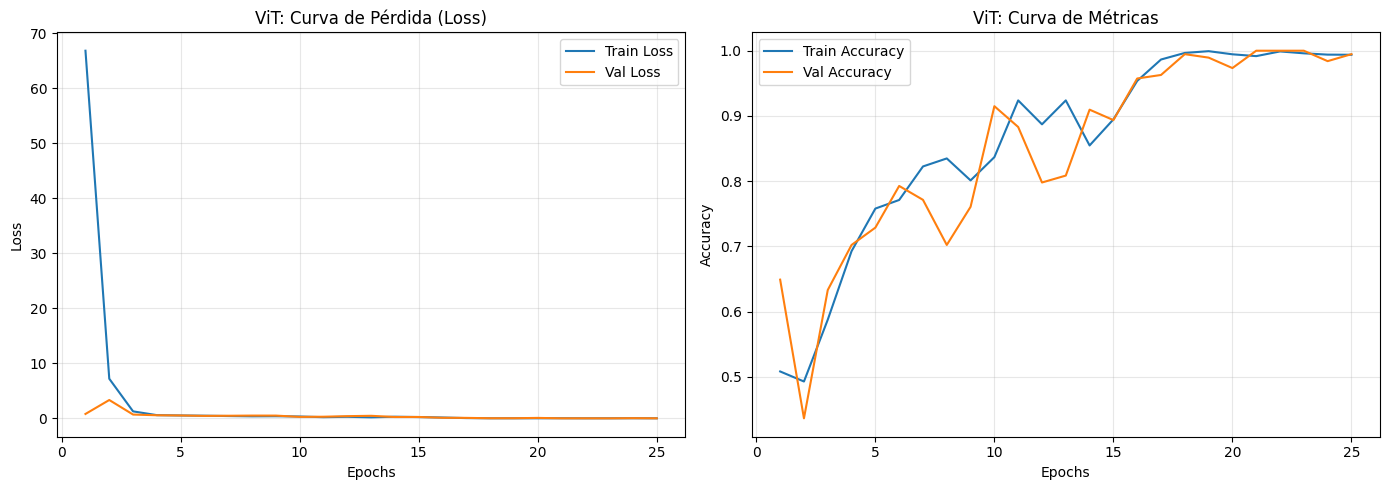

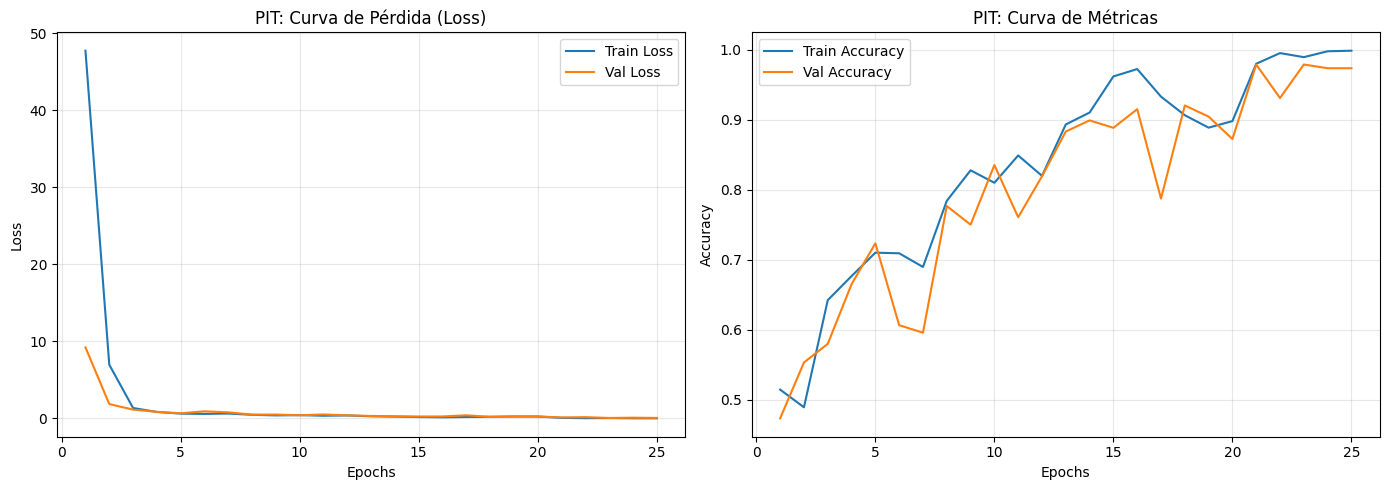

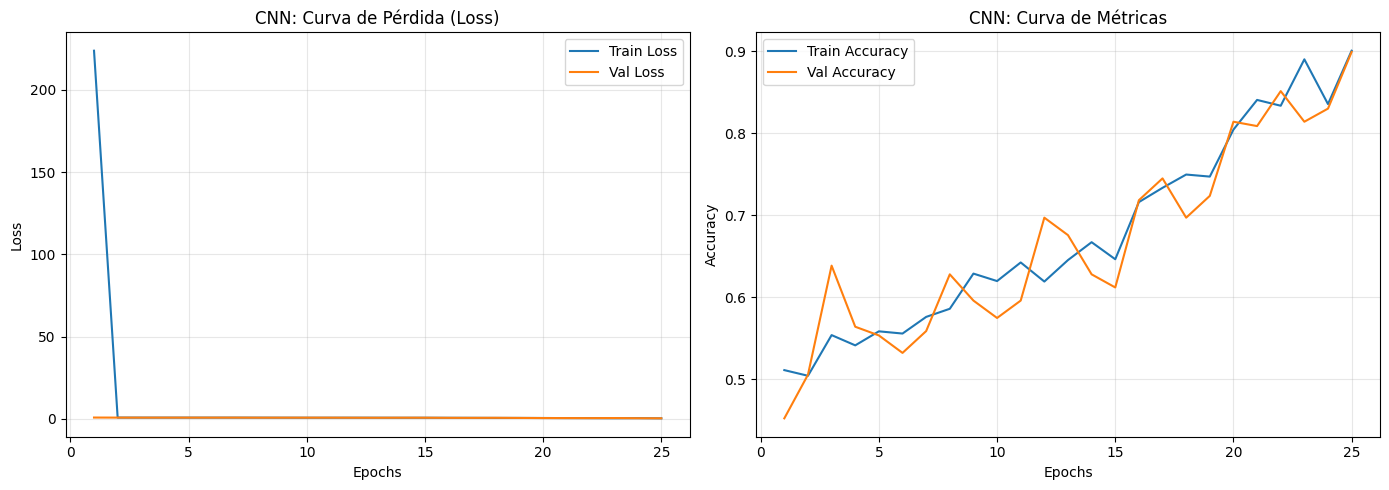

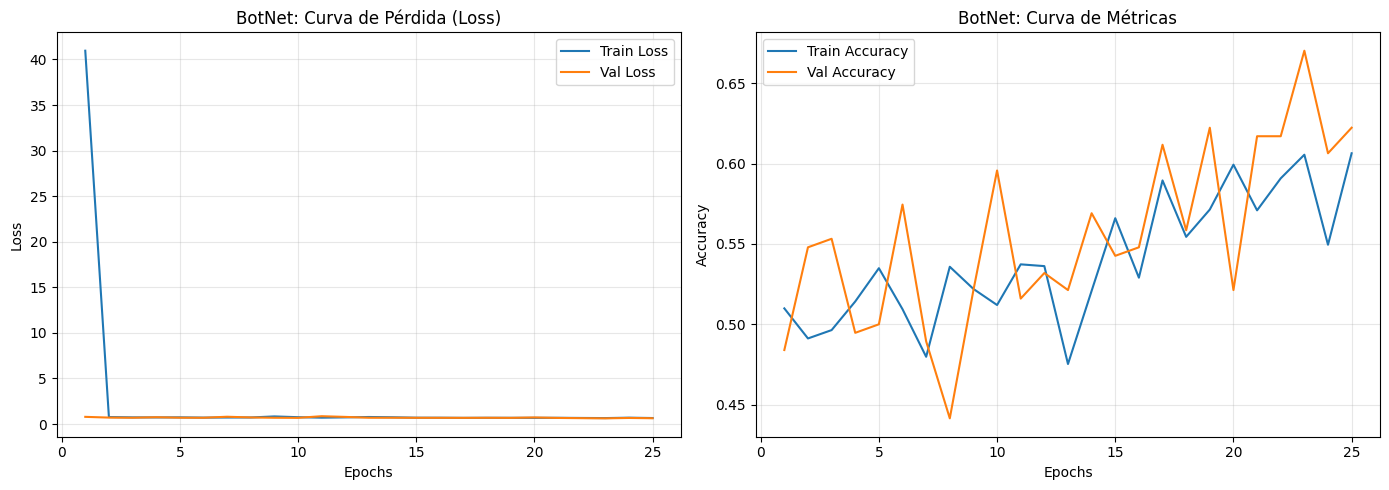

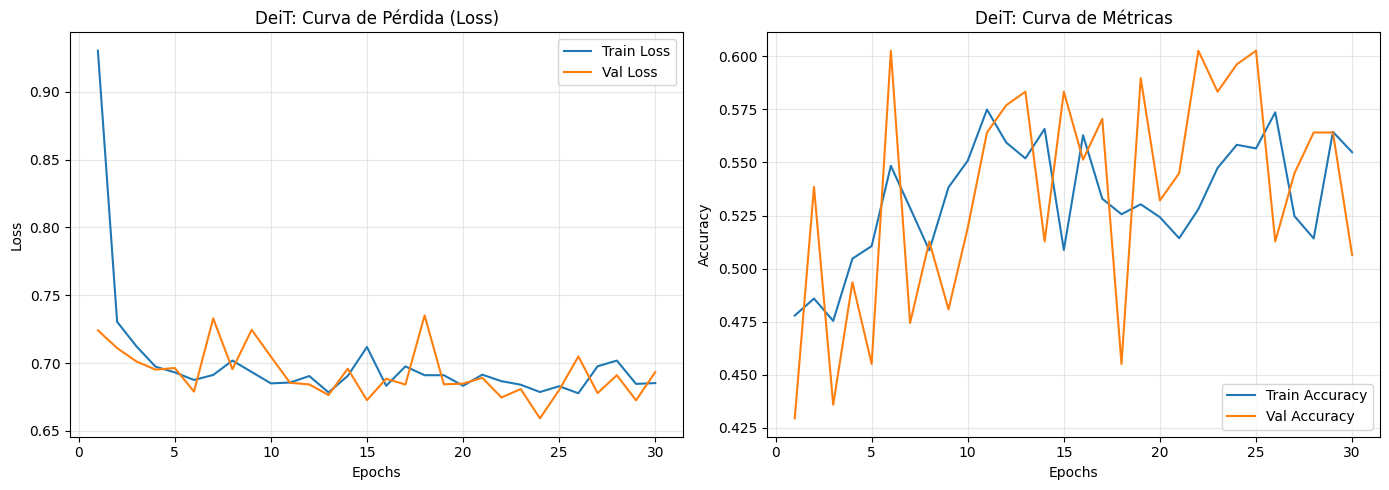

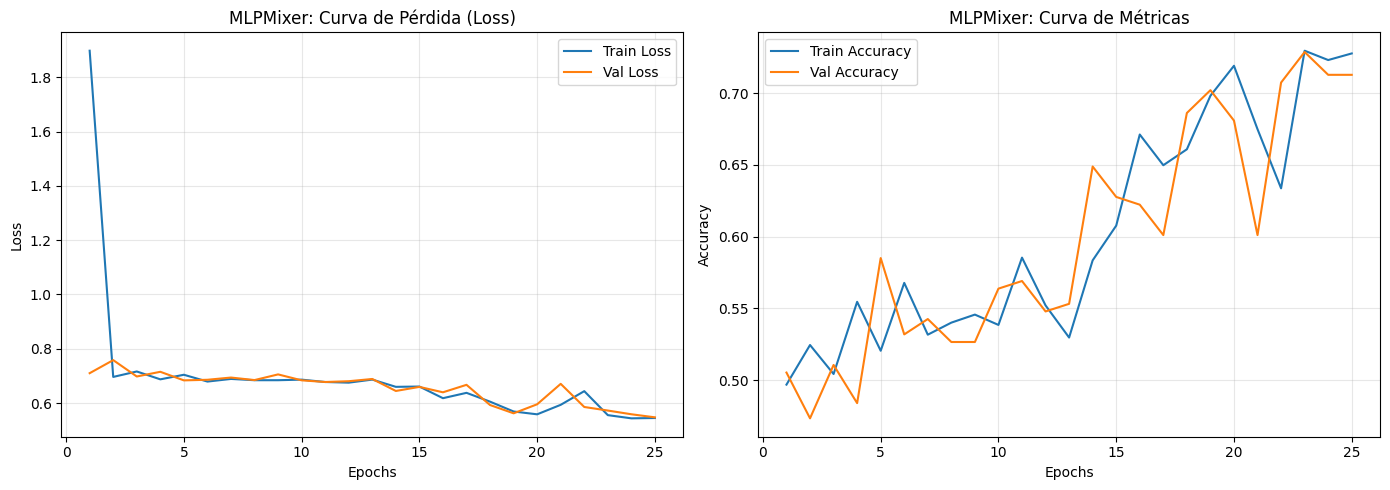

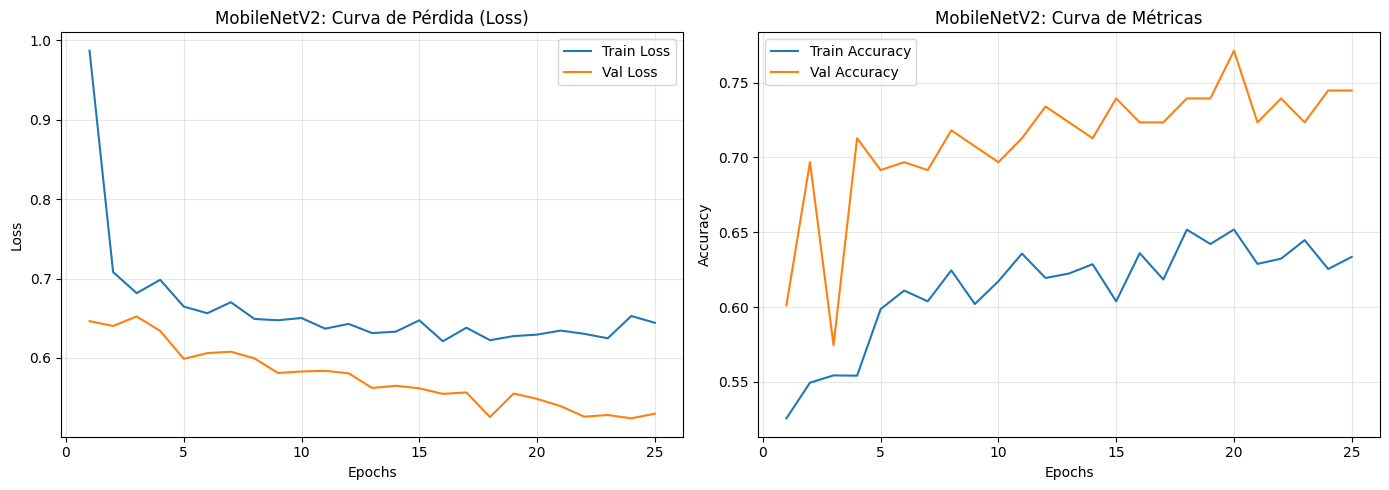

In [10]:
import json
import re
import matplotlib.pyplot as plt
import os

def extract_history_from_notebook(nb_path):
    """
    Extrae métricas de entrenamiento (loss, accuracy, precision, etc.) de las salidas de celdas de un cuaderno.
    """
    history = {
        'loss': [], 'val_loss': [],
        'accuracy': [], 'val_accuracy': [],
        'precision': [], 'val_precision': []
    }

    if not os.path.exists(nb_path):
        return None

    try:
        with open(nb_path, 'r', encoding='utf-8') as f:
            nb = json.load(f)
    except Exception as e:
        print(f"Error leyendo {nb_path}: {e}")
        return None

    for cell in nb['cells']:
        if 'outputs' in cell:
            for output in cell['outputs']:
                text_lines = []
                if 'text' in output:
                    text_lines = output['text']
                elif 'data' in output and 'text/plain' in output['data']:
                    text_lines = output['data']['text/plain']

                if isinstance(text_lines, str):
                    text_lines = text_lines.split('\n')

                for line in text_lines:
                    if 'loss:' in line and ('val_loss:' in line or 'step' in line):
                        metrics_found = re.findall(r'([a-z_]+):\s*([\d\.]+)', line)
                        current_epoch_metrics = {}
                        for name, val in metrics_found:
                            try:
                                current_epoch_metrics[name] = float(val)
                            except: pass

                        for key in history.keys():
                            search_keys = [key]
                            if key == 'accuracy': search_keys.append('acc')
                            if key == 'val_accuracy': search_keys.append('val_acc')

                            for sk in search_keys:
                                if sk in current_epoch_metrics:
                                    history[key].append(current_epoch_metrics[sk])
                                    break

    return {k: v for k, v in history.items() if len(v) > 0}

nb_map = {
    'ViT': '01_ViT_EGG.ipynb',
    'PIT': '02-PiT_EGG.ipynb',
    'CNN': '03-CNN_EGG.ipynb',
    'BotNet': '04-BotNet_EGG.ipynb',
    'DeiT': '05-DeIT_EGG.ipynb',
    'MLPMixer': '06-MLPMixer_EGG.ipynb',
    'MobileNetV2': ' 07_MOBILENETV2_EGG.ipynb'
}

print("Generando curvas de Historial de Entrenamiento extraídas de los cuadernos originales...\n")

for model_name, nb_file in nb_map.items():
    full_path = os.path.join(target_path, nb_file)
    if not os.path.exists(full_path):
        full_path = os.path.join(target_path, nb_file.strip())

    hist = extract_history_from_notebook(full_path)

    if hist and len(hist['loss']) > 0:
        # --- Corrección de Longitud Robusta ---
        # Manejar caso donde se capturan líneas duplicadas (ej. barra de progreso + final)
        loss_len = len(hist['loss'])
        val_loss_len = len(hist.get('val_loss', []))

        if val_loss_len > 0 and loss_len == 2 * val_loss_len:
             # Heurística: Si train es el doble que val, probablemente capturamos duplicados.
             # Tomamos cada 2do elemento (el final de la época)
             for k in hist:
                 if len(hist[k]) == loss_len:
                     hist[k] = hist[k][1::2]

        # Asegurar longitud mínima comón para evitar errores de dimension
        min_len = min(len(v) for v in hist.values())
        for k in hist:
            hist[k] = hist[k][:min_len]

        epochs = range(1, min_len + 1)

        plt.figure(figsize=(14, 5))

        # Gráfico de Loss
        plt.subplot(1, 2, 1)
        plt.plot(epochs, hist['loss'], '-', label='Train Loss')
        if 'val_loss' in hist:
            plt.plot(epochs, hist['val_loss'], '-', label='Val Loss')
        plt.title(f'{model_name}: Curva de Pérdida (Loss)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Gráfico de Métrica
        plt.subplot(1, 2, 2)
        has_metric = False
        if 'precision' in hist and len(hist['precision']) > 0:
             plt.plot(epochs, hist['precision'], '-', label='Train Precision')
             if 'val_precision' in hist:
                 plt.plot(epochs, hist['val_precision'], '-', label='Val Precision')
             plt.ylabel('Precision')
             has_metric = True

        if not has_metric and 'accuracy' in hist:
             plt.plot(epochs, hist['accuracy'], '-', label='Train Accuracy')
             if 'val_accuracy' in hist:
                 plt.plot(epochs, hist['val_accuracy'], '-', label='Val Accuracy')
             plt.ylabel('Accuracy')
             has_metric = True

        plt.title(f'{model_name}: Curva de Métricas')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print(f"\u26A0️ No se encontraron registros de entrenamiento para: {model_name}")

In [11]:
import pandas as pd
import json
import re
import os

# --- Generación de Tabla Comparativa Detallada (Test Set) ---

# Crear DataFrame a partir de los resultados de evaluación
if evaluation_results:
    results_df = pd.DataFrame(evaluation_results)

    # Función para extraer hiperparámetros del cuaderno fuente
    def get_hyperparameters(model_filename):
        nb_map = {
            '01_ViT_EEG_Alcohol_Detection.keras': '01_ViT_EGG.ipynb',
            '02_PiT_EEG_Alcohol_Detection.keras': '02-PiT_EGG.ipynb',
            '03_CNN_EEG_Alcohol_Detection.keras': '03-CNN_EGG.ipynb',
            '04_BotNet_EEG_Alcohol_Detection.keras': '04-BotNet_EGG.ipynb',
            '05_DEIT_EEG_Alcohol_Detection.keras': '05-DeIT_EGG.ipynb',
            '06_MLPMixer_EEG_Alcohol_Detection.keras': '06-MLPMixer_EGG.ipynb',
            '07_MobileNetV2_EEG.keras': ' 07_MOBILENETV2_EGG.ipynb'
        }

        nb_name = nb_map.get(model_filename)
        if not nb_name: return "batch_size: ?; epochs: ?; learning_rate: ?; optimizer: ?"

        # Intentar ruta con target_path global o hardcoded
        base_path = '/content/drive/MyDrive/Papper_Titulo /'
        path = os.path.join(base_path, nb_name)
        if not os.path.exists(path):
             path = os.path.join(base_path, nb_name.strip())
             if not os.path.exists(path): return "batch_size: ?; epochs: ?; learning_rate: ?; optimizer: ?"

        params = {
            'batch_size': '?',
            'epochs': '?',
            'learning_rate': '?',
            'optimizer': '?'
        }

        try:
            with open(path, 'r', encoding='utf-8') as f:
                nb = json.load(f)

            source_code = ""
            for cell in nb['cells']:
                if cell['cell_type'] == 'code':
                    source_code += "".join(cell['source']) + "\n"

            # Búsqueda Regex para Hiperparámetros
            bs_match = re.search(r'batch_size\s*=\s*(\d+)', source_code)
            if bs_match: params['batch_size'] = bs_match.group(1)

            ep_match = re.search(r'epochs\s*=\s*(\d+)', source_code)
            if ep_match: params['epochs'] = ep_match.group(1)

            lr_match = re.search(r'learning_rate\s*=\s*([\d.e-]+)', source_code)
            if not lr_match:
                 lr_match = re.search(r'lr\s*=\s*([\d.e-]+)', source_code)
            if lr_match: params['learning_rate'] = lr_match.group(1)

            # Heurística para optimizador
            if 'Adam' in source_code: params['optimizer'] = 'Adam'
            elif 'SGD' in source_code: params['optimizer'] = 'SGD'
            elif 'RMSprop' in source_code: params['optimizer'] = 'RMSprop'
            elif 'Adagrad' in source_code: params['optimizer'] = 'Adagrad'
            else:
                opt_match = re.search(r"optimizer\s*=\s*['\"]?(\w+)['\"]?", source_code, re.IGNORECASE)
                if opt_match and opt_match.group(1).lower() not in ['tf', 'keras', 'layers']:
                     params['optimizer'] = opt_match.group(1)

        except Exception as e:
            print(f"Error analizando {nb_name}: {e}")

        return f"batch_size: {params['batch_size']}; epochs: {params['epochs']}; learning_rate: {params['learning_rate']}; optimizer: {params['optimizer']}"

    # Función para obtener información detallada del modelo
    def get_model_details(filename):
        # Returns: (Model Name, Deep Learning Type, Model Type)
        if 'PiT' in filename:
            return 'PIT', 'Hybrid', 'Pooling-based Vision Transformer'
        elif 'ViT' in filename and 'Mobile' not in filename:
            return 'ViT', 'Transformer', 'Vision Transformer'
        elif 'CNN' in filename:
            return 'CNN', 'CNN', 'Custom CNN'
        elif 'MLPMixer' in filename:
            return 'MLPMixer', 'MLP', 'MLP-Mixer'
        elif 'MobileNetV2' in filename:
            return 'MobileNetV2', 'CNN', 'MobileNetV2'
        elif 'MOBILEVIT' in filename:
            return 'MobileViT', 'Hybrid', 'MobileViT'
        elif 'DEIT' in filename:
            return 'DeiT', 'Transformer', 'Data-efficient Image Transformer'
        elif 'BotNet' in filename:
            return 'BotNet', 'Hybrid', 'Bottleneck Transformer'
        return filename, 'Unknown', 'Unknown'

    # Aplicar transformación para obtener las nuevas columnas
    results_df['Hyperparameters'] = results_df['Model'].apply(get_hyperparameters)

    # Obtener detalles y asignar columnas de manera segura
    details_list = results_df['Model'].apply(get_model_details).tolist()
    results_df['Model'] = [item[0] for item in details_list]
    results_df['Deep Learning Type'] = [item[1] for item in details_list]
    results_df['Model Type'] = [item[2] for item in details_list]

    # Seleccionar y reordenar columnas
    columns_to_show = [
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'Inference Time',
        'Deep Learning Type',
        'Model Type',
        'Hyperparameters'
    ]

    # Asegurarse de que todas las columnas existan
    results_df = results_df[columns_to_show]

    # Ordenar por Accuracy descendente
    results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

    # Ajustar índice para comenzar en 1
    results_df.index = results_df.index + 1

    # Mostrar la Tabla Comparativa
    print("Comparative Model Evaluation Table (Test Set - Split Original):")
    pd.set_option('display.max_colwidth', None)
    display(results_df)

    # Identificar e imprimir el mejor modelo
    best_model_row = results_df.iloc[0]
    print(f"\nBest Model: {best_model_row['Model']}")
    print(f"Highest Accuracy: {best_model_row['Accuracy']:.4f}")
else:
    print("No evaluation results available to compile.")

Comparative Model Evaluation Table (Test Set - Split Original):


,Model,Accuracy,Precision,Recall,F1-Score,Inference Time,Deep Learning Type,Model Type,Hyperparameters
1,ViT,0.994595,0.994658,0.994595,0.994597,9.617657,Transformer,Vision Transformer,batch_size: 32; epochs: 25; learning_rate: 0.001; optimizer: Adam
2,PIT,0.994595,0.994648,0.994595,0.994592,4.018364,Hybrid,Pooling-based Vision Transformer,batch_size: 32; epochs: 25; learning_rate: 0.001; optimizer: Adam
3,CNN,0.881081,0.882269,0.881081,0.881263,10.411890,CNN,Custom CNN,batch_size: 32; epochs: 25; learning_rate: 0.001; optimizer: Adam
4,MLPMixer,0.735135,0.736176,0.735135,0.735462,21.682475,MLP,MLP-Mixer,batch_size: 32; epochs: 25; learning_rate: 0.001; optimizer: Adam
5,MobileNetV2,0.729730,0.731237,0.729730,0.730142,20.992505,CNN,MobileNetV2,batch_size: 32; epochs: ?; learning_rate: 0.001; optimizer: Adam
6,BotNet,0.643243,0.643243,0.643243,0.643243,26.156880,Hybrid,Bottleneck Transformer,batch_size: 32; epochs: 25; learning_rate: 0.001; optimizer: Adam



Best Model: ViT
Highest Accuracy: 0.9946


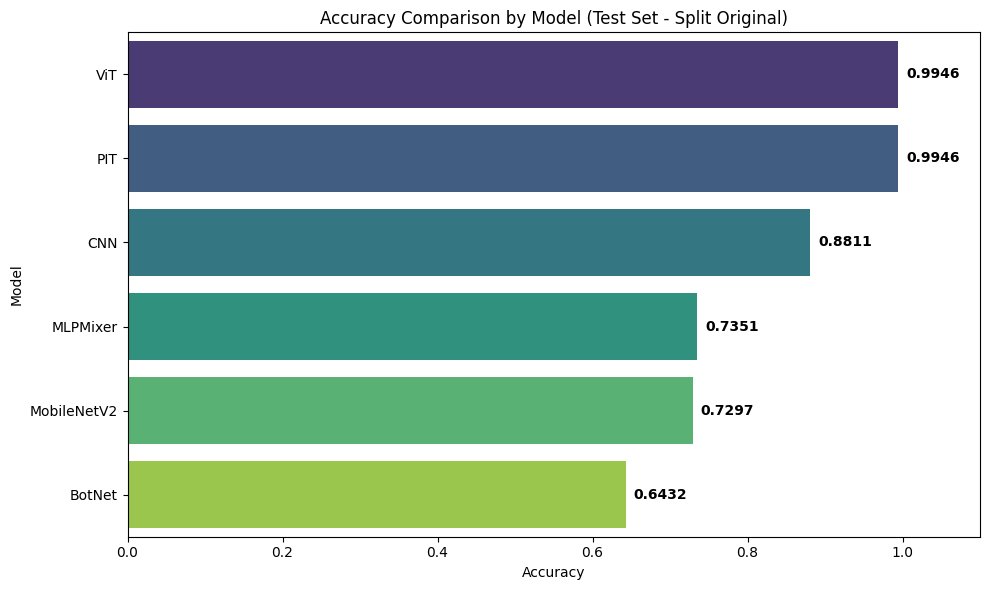

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Verificar si el DataFrame con los resultados existe
if 'results_df' in locals() and not results_df.empty:
    plt.figure(figsize=(10, 6))

    # Crear el gráfico de barras usando las columnas en Inglés
    # x='Accuracy', y='Model'
    barplot = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis', hue='Model', legend=False)

    plt.title('Accuracy Comparison by Model (Test Set - Split Original)')
    plt.xlabel('Accuracy')
    plt.ylabel('Model')
    plt.xlim(0, 1.1)  # Límite para dar espacio a las etiquetas

    # Añadir los valores numéricos al final de cada barra
    # Iterar sobre la columna 'Accuracy'
    for i, v in enumerate(results_df['Accuracy']):
        barplot.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Error: No se encontraron datos (results_df). Por favor, asegúrese de ejecutar primero la celda que genera la tabla comparativa (results_df).")

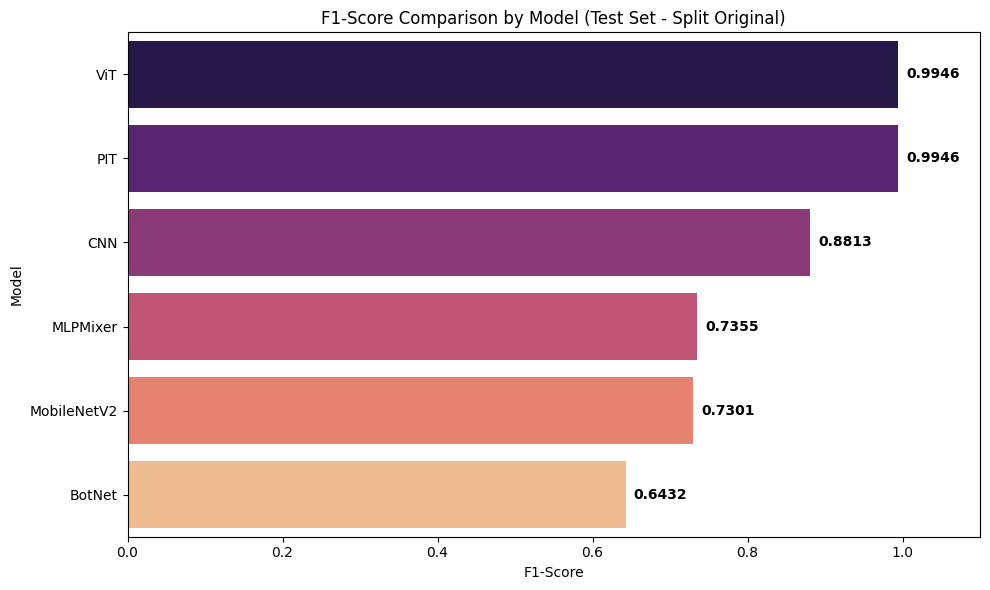

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'results_df' in locals() and not results_df.empty:
    plt.figure(figsize=(10, 6))
    # Crear el gráfico de barras para F1-Score
    barplot = sns.barplot(x='F1-Score', y='Model', data=results_df, palette='magma', hue='Model', legend=False)

    plt.title('F1-Score Comparison by Model (Test Set - Split Original)')
    plt.xlabel('F1-Score')
    plt.ylabel('Model')
    plt.xlim(0, 1.1)

    for i, v in enumerate(results_df['F1-Score']):
        barplot.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No data found to plot.")

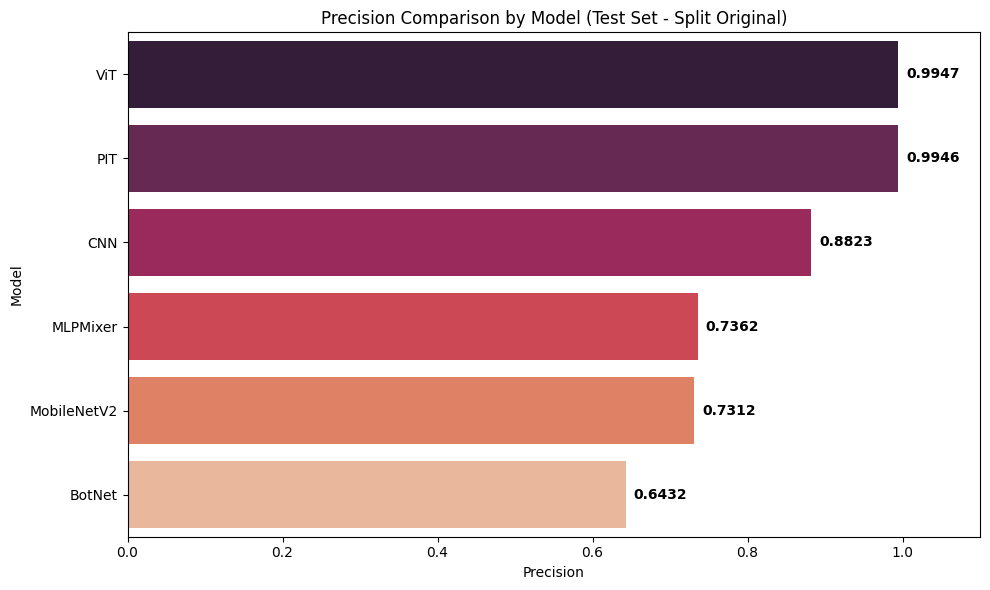

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'results_df' in locals() and not results_df.empty:
    plt.figure(figsize=(10, 6))
    # Crear el gráfico de barras para Precision
    barplot = sns.barplot(x='Precision', y='Model', data=results_df, palette='rocket', hue='Model', legend=False)

    plt.title('Precision Comparison by Model (Test Set - Split Original)')
    plt.xlabel('Precision')
    plt.ylabel('Model')
    plt.xlim(0, 1.1)

    for i, v in enumerate(results_df['Precision']):
        barplot.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No data found to plot.")

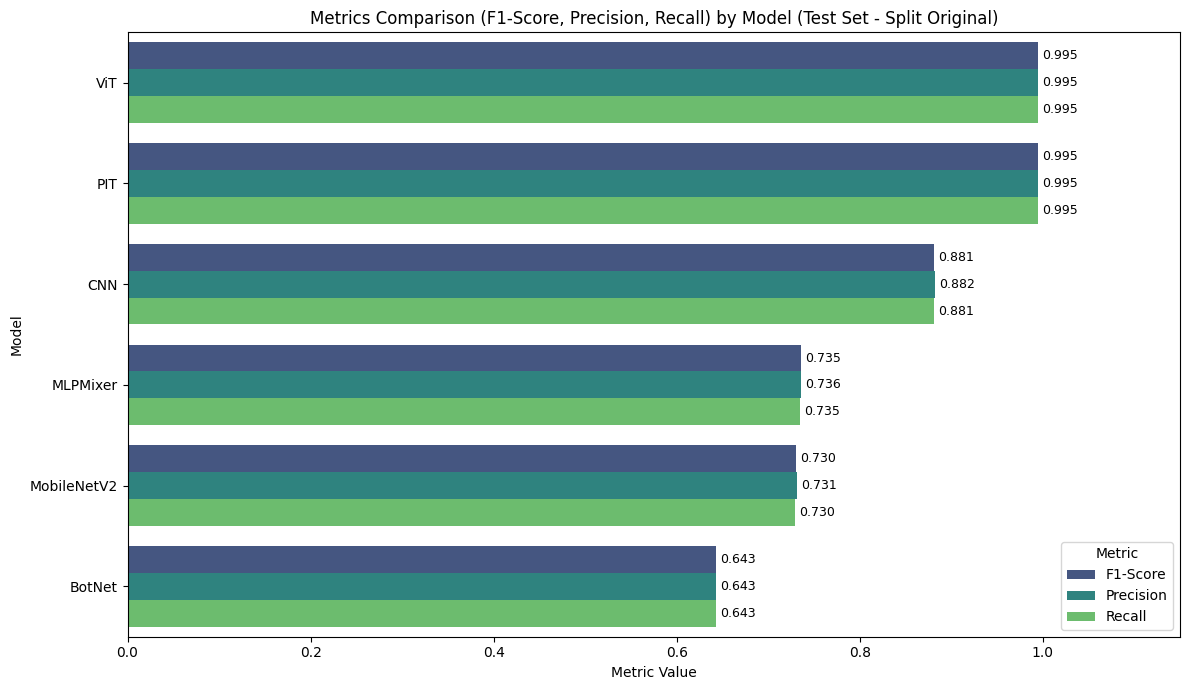

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'results_df' in locals() and not results_df.empty:
    # Transformar el DataFrame a formato largo para seaborn (melt)
    melted_df = results_df.melt(id_vars=['Model'],
                                   value_vars=['F1-Score', 'Precision', 'Recall'],
                                   var_name='Metric',
                                   value_name='Value')

    plt.figure(figsize=(12, 7))

    # Crear el gráfico de barras agrupado
    barplot = sns.barplot(x='Value', y='Model', hue='Metric', data=melted_df, palette='viridis')

    plt.title('Metrics Comparison (F1-Score, Precision, Recall) by Model (Test Set - Split Original)')
    plt.xlabel('Metric Value')
    plt.ylabel('Model')
    plt.xlim(0, 1.15)
    plt.legend(title='Metric', loc='lower right')

    # Añadir los valores numéricos al final de cada barra
    for container in barplot.containers:
        barplot.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No data found to plot.")

In [16]:
import os

# Definir nombre del archivo de salida
output_csv_file = 'comparison_results.csv'
output_path = os.path.join(target_path, output_csv_file)

if 'results_df' in locals() and not results_df.empty:
    try:
        # Guardar en CSV
        results_df.to_csv(output_path, index=False)
        print(f"Resultados ORIGINALES guardados exitosamente en: {output_path}")

        # Mostrar primeras filas como confirmación
        print("\nVista previa del archivo guardado:")
        print(results_df.head())

    except Exception as e:
        print(f"Error al guardar los resultados: {e}")
else:
    print("No hay datos en 'results_df' para guardar. Asegúrese de generar la tabla comparativa primero.")

Resultados ORIGINALES guardados exitosamente en: /content/drive/MyDrive/Papper_Titulo /comparison_results.csv

Vista previa del archivo guardado:
         Model  Accuracy  Precision    Recall  F1-Score  Inference Time  \
1          ViT  0.994595   0.994658  0.994595  0.994597        9.617657   
2          PIT  0.994595   0.994648  0.994595  0.994592        4.018364   
3          CNN  0.881081   0.882269  0.881081  0.881263       10.411890   
4     MLPMixer  0.735135   0.736176  0.735135  0.735462       21.682475   
5  MobileNetV2  0.729730   0.731237  0.729730  0.730142       20.992505   

  Deep Learning Type                        Model Type  \
1        Transformer                Vision Transformer   
2             Hybrid  Pooling-based Vision Transformer   
3                CNN                        Custom CNN   
4                MLP                         MLP-Mixer   
5                CNN                       MobileNetV2   

                                                     H